In [ ]:
##Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
##Data:
df = pd.read_csv('/content/updated_cleaned_school.csv')

# Step 1: Introduction

**Context:**

A person's childhood is often their most important, and formative years of their life. Experiencing traumatic events can change a child's world view, shaping how they see and view individuals. If severe, these experiences can lead to children beginning to fear for their safety, and subsequent changes in their personality. Our goal is to figure out which risks/crimes a child fears the most, so further resources can be allocated in protecting children from experiencing them.

**Research Question:**  Which crime and school behavioral exposures are associated with the highest levels of fear among US students?

**Dataset:**

**We** will be using the National Center for Education Statistics's 2022 School Crime Supplement dataset, which interviews students 12-18 on topics such as:
- Bullying
- Fighting
- Drugs/Alcohol
- Exposure to Crime

The dataset samples 12335 individuals from all across the US, with over 900 pieces of information (columns). It's one of the most extensive sources on crime in relation to students, and given it's published by the government, is also trustworthy.

**Data Overview:**
The data was processed and cleaned so the data was tailored to be properly used for the following analysis. Our final dataset includes the following:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4589 entries, 0 to 4588
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             4589 non-null   int64  
 1   sex                             4589 non-null   object 
 2   race                            4589 non-null   object 
 3   hispanic_origin                 4589 non-null   object 
 4   education                       4589 non-null   object 
 5   current_grade                   4589 non-null   object 
 6   school_type                     4589 non-null   object 
 7   school_locale                   4589 non-null   object 
 8   school_level                    4589 non-null   object 
 9   safe_at_school                  4589 non-null   int64  
 10  crime_in_neighborhood           4589 non-null   int64  
 11  name_calling                    4589 non-null   int64  
 12  rumors                          45

##

# Step 2: Show the Data and Key Findings

### a) Demographics

####**Introduction:**
Before diving into the research question, it's intially important to understand who we are drawing conclusions from. To do this, we will be exploring the demographics of the student's we'll be studying, and what conclusions can be drawn using visualizations.

#### **Age:**

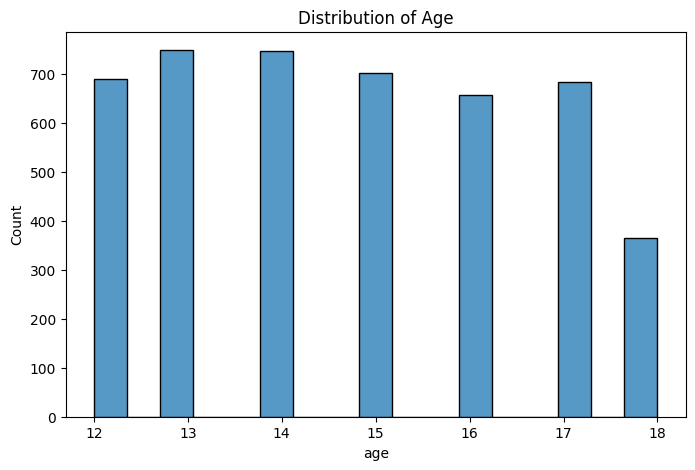

In [ ]:
##Age:
plt.figure(figsize=(8,5))
plt.title('Distribution of Age')
sns.histplot(df['age'])
plt.show()

**Observation:** There is a fairly uniform distribution of students aged 12-17, however there are significantly less 18 year old students.

**Why:** This is likely because most high school students graduate at ages 17-18, meaning not everyone is 18 at the time of graduation.

**Note:** Because middle school in the US only has 3 years while high school has 4, this survey may be bias towards High School Students.

**Takeaway:** Students from all school grades were sampled relatively equally, with their being less 18 year olds because most high school graduates are not 18.

#### **Gender:**

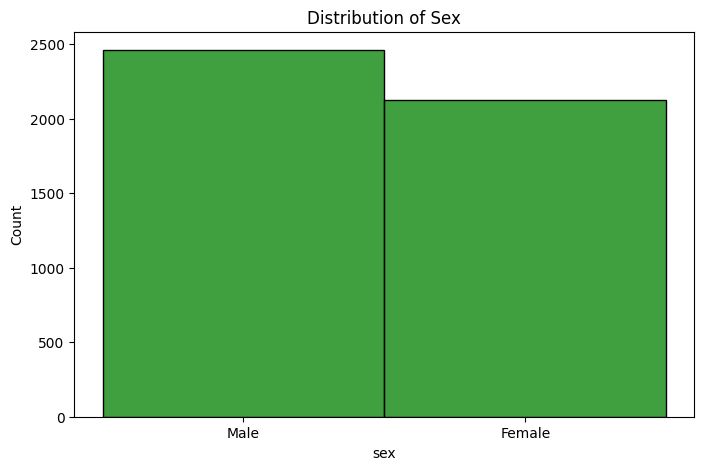

In [ ]:
##Sex:
plt.figure(figsize=(8,5))
plt.title('Distribution of Sex')
sns.histplot(df['sex'], color = 'green')
plt.show()

**Observation:** There are more males in our dataset than females.

**Why:** This could be the result of sampling bias, or the result of our cleaneed dataset. Because we ended up deleting many entries in the process, this could made what was intially a ~50/50 split into a ~54/46.

**Takeaway:** Our dataset slightly favors a male demographic, but is not drastic/skewed enough to be of concern.

#### **Race:**

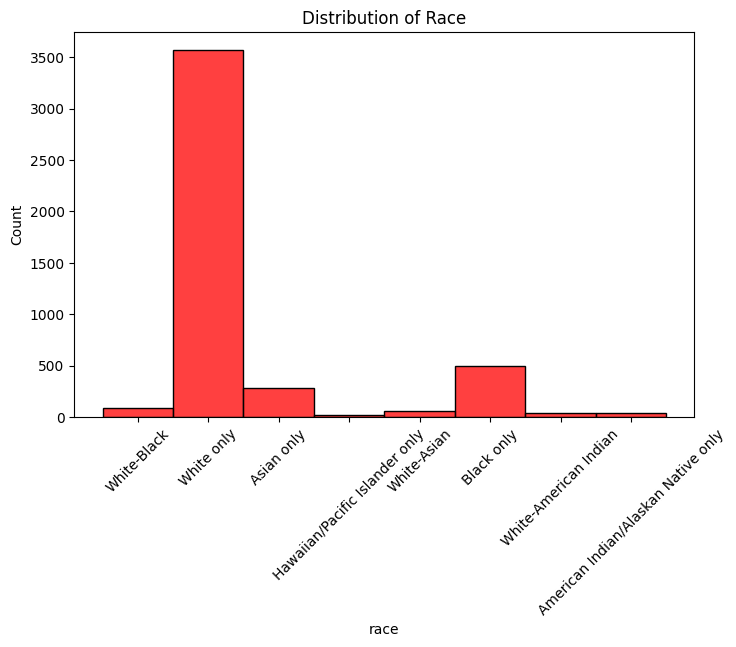

In [ ]:
##Race:
plt.figure(figsize=(8,5))
plt.title('Distribution of Race')
sns.histplot(df['race'], color = 'red')
plt.xticks(rotation=45)
plt.show()

**Observation:** Our data is heavily skewed towards white students.

**Why:** Given this survey samples the whole United States, this should've been expected. The US is a primarily white country, so it should be expected the most popular race is white.

**Takeaway:** Due to the scope of our sample, our population is primarily white. This is something we should consider while observing our data.

### b) Risk Factors

####**Introduction:**

Now that we know our audience, it's time to uncover each risk factor and explore their trends and patterns (individually, and in relation to another). Each Risk factor was pulled from the dataset and assessed into one of 4 categories:
Risk factors are made up of 4 categories:
1) Verbal Bullying
2) Physical Bullying
3) Drug/Alcohol Availability
4) Exposure to Crime

Each Risk factor has a sum (total number of experiences) and a mean (overall score from 0-1), allowing us each risk's distribution, and use it's mean for later statistical work.

#### **Overview:**

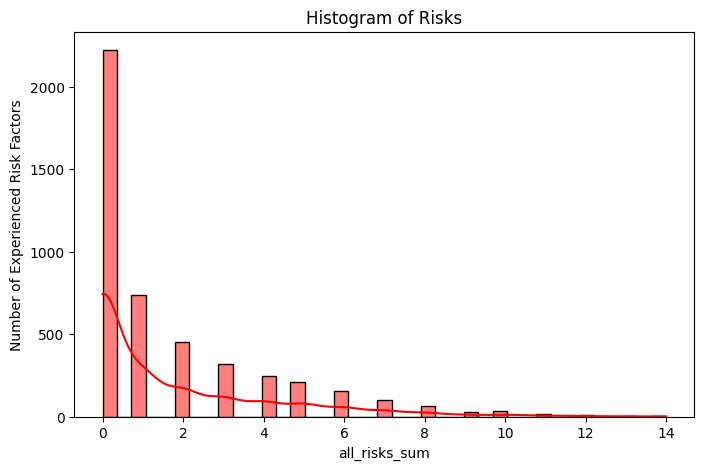

In [ ]:
##Histogram of all Crimes dist.
plt.figure(figsize=(8, 5))
sns.histplot(x=df["all_risks_sum"], kde= True,color="red")
plt.title("Histogram of Risks")
plt.ylabel("Number of Experienced Risk Factors")
plt.show()

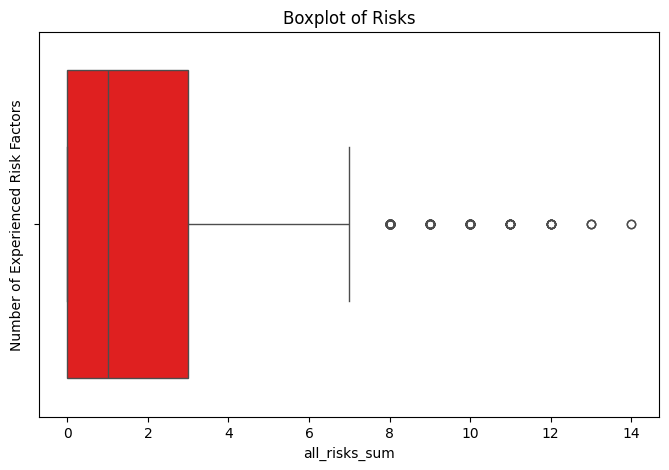

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["all_risks_sum"],color="red")
plt.title("Boxplot of Risks")
plt.ylabel("Number of Experienced Risk Factors")
plt.show()

**Context:** This first graph shows the total number of experiences, summing all risks together into one graph.

**Observation:** This graph is incredibly skewed right.

**Why:** Most students don't experience many crime-related experiences. Whether that's because of the enviroment or parenting, it's the most popular column is students who have yet to have an experience with bullying, alcohol, and crime.

**Conclusion** ~50% of our sample have yet have a experience related to bullying, drugs, or crime. While the other ~50% may have experience some sort of risk, most students have only witnessed 1-3 at most. (50-75% Percentile)



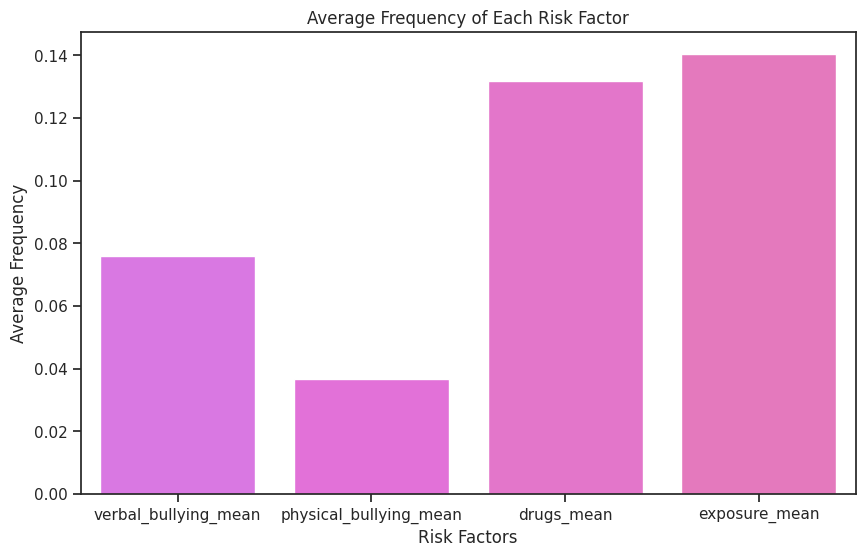

In [ ]:
# This plots the mean automatically with confidence intervals
plt.figure(figsize=(10, 6))
sns.barplot(data=df, order=['verbal_bullying_mean', 'physical_bullying_mean', 'drugs_mean', 'exposure_mean'], errorbar=None)

plt.title('Average Frequency of Each Risk Factor')
plt.ylabel('Average Frequency')
plt.xlabel('Risk Factors')
plt.show()

In [ ]:
exact_means = df[['verbal_bullying_mean', 'physical_bullying_mean', 'drugs_mean', 'exposure_mean']].mean()

print(exact_means)

verbal_bullying_mean      0.075877
physical_bullying_mean    0.036718
drugs_mean                0.131837
exposure_mean             0.140445
dtype: float64


#### **Distributions of Each Risk Factor:**

<Axes: title={'center': 'Distributions for Each Risk Factor'}, ylabel='Frequency (each tick = +1 event)'>

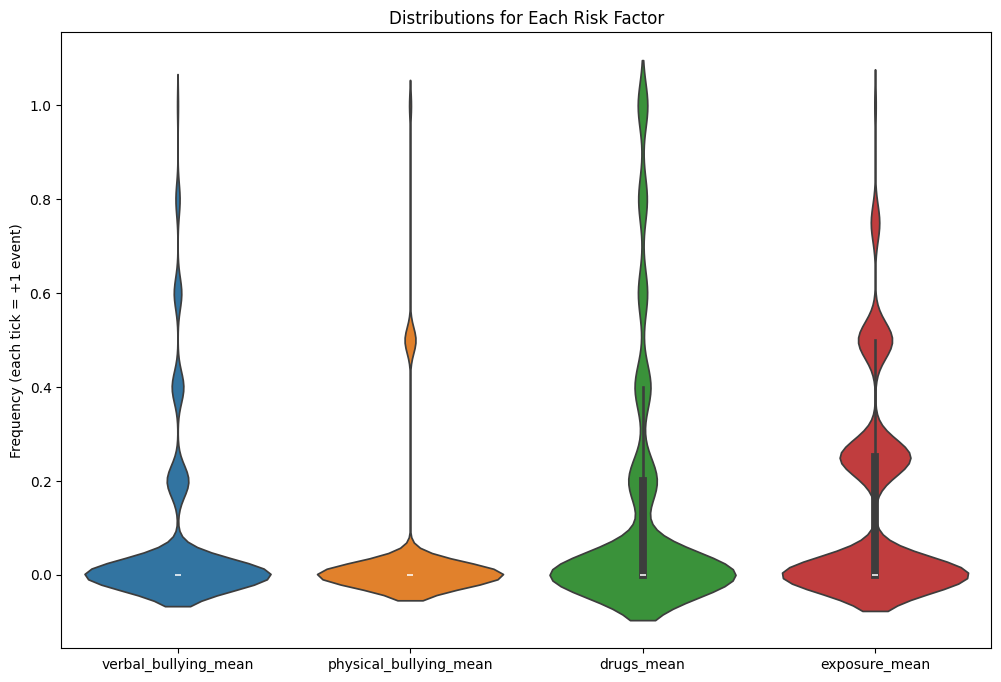

In [ ]:
##Stacked Histogram:
plt.figure(figsize=(12, 8))
plt.title('Distributions for Each Risk Factor')
plt.ylabel('Frequency (each tick = +1 event)')
sns.violinplot(
    data = df[['verbal_bullying_mean', 'physical_bullying_mean','drugs_mean', 'exposure_mean']],
    fill = True
)

**Context:** This graph shows each risk factor's distribution. (0 = No experience, 1= Experienced all in category).

**Observation:** All risk factors are severely skewed right, with drugs and exposure to crime being the most common of the 4.

**Why:** Recall our risk factor hisogram. In it, we saw many students rarely experienced many of the following events. This is why our distribution for each risk is so skewed, with many students never having gone through over 2-3 of these experiences. Additionally, having access/indulging in alochol is something most children have done atleast once. For example, taking a sip of their father's wine. Additionally, it's rare but not impossible to see students doing drugs or other crime-related activities in your neighborhood.

**Conclusion:** Many students have rarely ever experienced any of these risks, with their being a slight bias towards availability in drugs and exposure to crime.

### c) Fear of Being Attacked at School

**Introduction:**



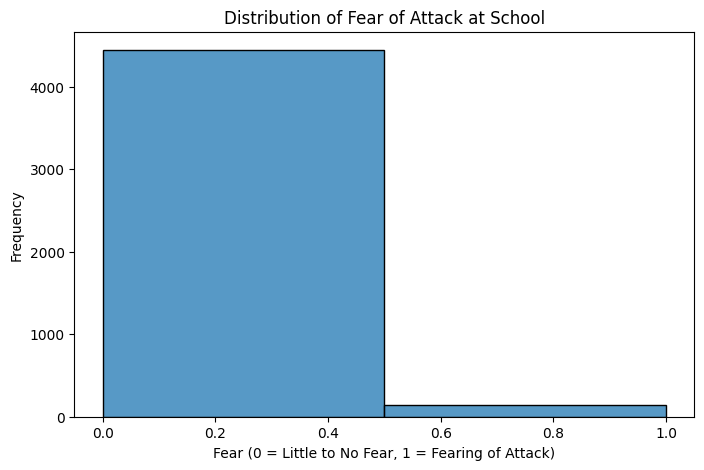

In [ ]:
## Fear of Attack at School:
plt.figure(figsize=(8,5))
sns.histplot(df['adjusted_fear_at_school'], bins=2)
plt.title('Distribution of Fear of Attack at School')
plt.xlabel('Fear (0 = Little to No Fear, 1 = Fearing of Attack)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['adjusted_fear_at_school'].value_counts().sort_index()

,count
adjusted_fear_at_school,
0,4442
1,147


**Context:** This graph shows whether or not a student fears an attack at school or not.

**Observation:** There is clearly way more students who do not fear an attack compared to those who do.

**Why:** Many students who have likely grew up in healthy and supportive enviroments have never even had the idea they would be attacked in school. Those who do fear an attack definetly have experience with a traumatic event prior, cauing them to worry over their safety.

**Conclusion:** ~95% of students do not fear an attack at school, while the other ~5% do. The skewedness in our data means we likely need to take our conclusions with a grain of salt.

d) Solving the Research Question:

#### **Correlation Matrix of Crime Factors and School Fear:**

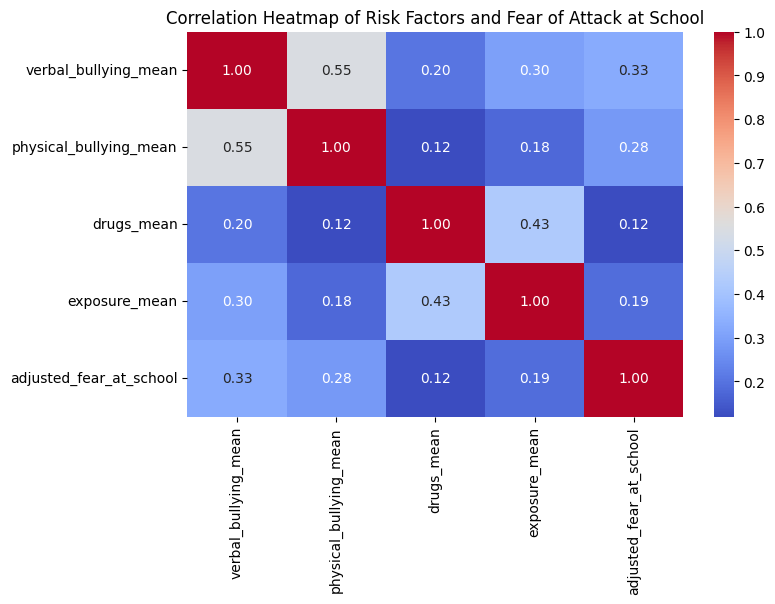

In [ ]:
##Using all of our risk factors:
risk_factors = ['verbal_bullying_mean', 'physical_bullying_mean',
                'drugs_mean', 'exposure_mean', 'adjusted_fear_at_school']

#Correlation HeatMap:
plt.figure(figsize=(8, 5))
sns.heatmap(df[risk_factors].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Risk Factors and Fear of Attack at School")
plt.show()

### Assessing Correlation between Risk Factors:

**Context:** The following graph is a correlation matrix between all of our risk factors, as well as fear of being attacked at school.

**Observation:** Physical and Verbal Bullying have a fairly strong linear correlation to one another, alongside exposure to crime and drug availability.

**Why:** Verbal and Physical bullying are expected to be correlated, because if someone was bullying you in one form, more likely than not they will hurt you in the other way as well. The correlation between drugs and crime exposure might be because both are tied to observing rather than doing directly. Knowing if a drug or seeing a crime unfold is more rare than having experienced bullying directly.

**Conclusion:** There are two roughly linear patterns:
1) Verbal and Physical Bullying (If you experience one, you will likely experience the latter)
2) Exposure to crime and drug availability. (Both observational experiences, aka. events that are seen not done)

### Assessing Correlation of Risk Factors and Fear of Attack:

**Observation:** There seems to be a fairly weak correlation between all of our factors and fear of being attacked at school. However, there is a weak correlation between bullying and fear of attack.

**Why:** Just because a student has experienced some of the following events does not mean it will cause them to start fearing attacks at school. There is likely a confounding variable we are not accounting for which does directly cause a student to be fearful of attacks, but have yet to consider it.

**Conclusion:** While there is a weak correlation between fear of attack and bullying, it's not strong enough to imply it's the main reason why a student fears being attacked. There is likely an underlying reason we may not be accounting for, or the relationships between the risk factors and target are non-linear.

#### Logistic Regression:

In [ ]:
##Defining variables:
X = df[['verbal_bullying_mean', 'physical_bullying_mean',
                'drugs_mean', 'exposure_mean']]
Y = df['adjusted_fear_at_school']

##Train and Test Split:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=127)

##Logistic Regression:
model = LogisticRegression()
model.fit(X_train, Y_train)

##Intercept and coefficients:
intercept = model.intercept_[0]
coeff = model.coef_[0]

print(f'The model intercept: {intercept} amd coefficents: {coeff}')
print('')
##Calculating the odd ratios (quantify strength of assocation between risk and fear)
odd_ratios = np.exp(coeff)

for col, coef, or_val in zip(X, coeff, odd_ratios):
  print(f'Feature: {col}')
  print(f'Coefficent (Log_Odds): {coef}')
  print(f'Odds Ratio (OR): {or_val}')
  print(f'For every unit increase in {col}, the odds of a student fearing an attack at school changes by {or_val}')
  print('')

The model intercept: -4.767521522888362 amd coefficents: [2.85871485 1.60756017 0.77084991 1.63694234]

Feature: verbal_bullying_mean
Coefficent (Log_Odds): 2.8587148451545494
Odds Ratio (OR): 17.439100584382732
For every unit increase in verbal_bullying_mean, the odds of a student fearing an attack at school changes by 17.439100584382732

Feature: physical_bullying_mean
Coefficent (Log_Odds): 1.607560171466967
Odds Ratio (OR): 4.990620104427482
For every unit increase in physical_bullying_mean, the odds of a student fearing an attack at school changes by 4.990620104427482

Feature: drugs_mean
Coefficent (Log_Odds): 0.7708499123599213
Odds Ratio (OR): 2.161602646094265
For every unit increase in drugs_mean, the odds of a student fearing an attack at school changes by 2.161602646094265

Feature: exposure_mean
Coefficent (Log_Odds): 1.636942336891322
Odds Ratio (OR): 5.139430814677742
For every unit increase in exposure_mean, the odds of a student fearing an attack at school changes by 5

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

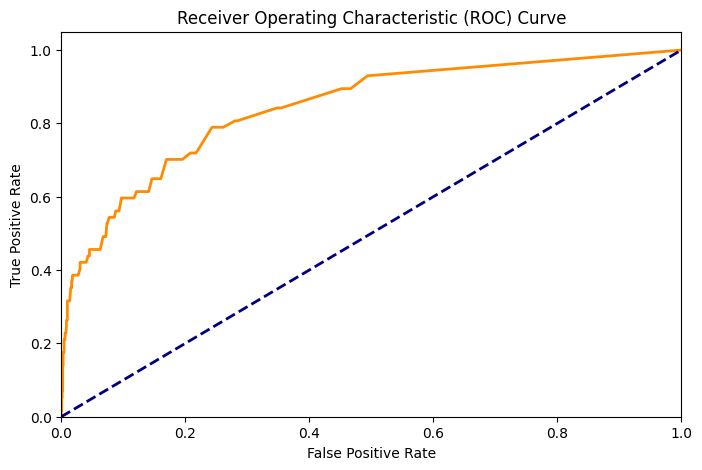

In [ ]:
##Prediction with Model:
y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[:,1]

##ROC/AUC Curve:
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
roc_auc = roc_auc_score(Y_test, Y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt

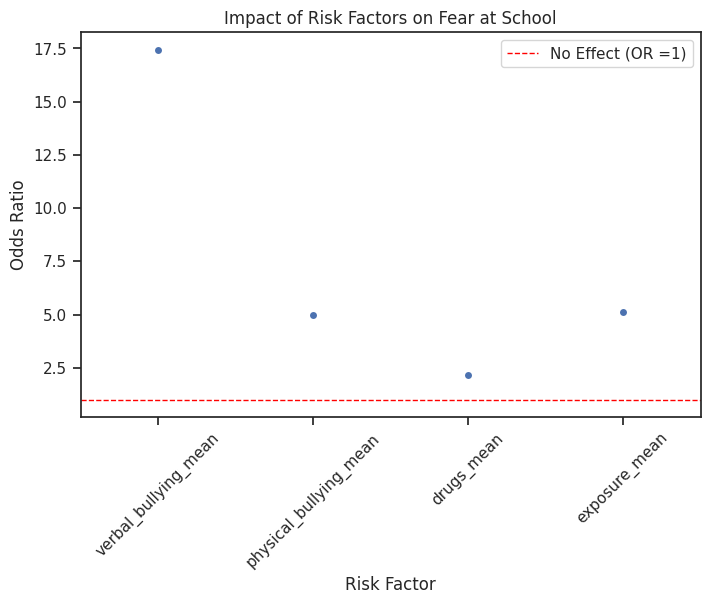

In [ ]:
##Converting into a DF
results = pd.DataFrame({"Risk Factor": X.columns, "Odds Ratio": odd_ratios})

##Plotting:
plt.figure(figsize=(8,5))
sns.set_theme(style='ticks')
plt.title('Impact of Risk Factors on Fear at School')
plt.axhline(y=1.0, color = 'red', linestyle = '--', linewidth = 1, label = 'No Effect (OR =1)')
sns.stripplot(x="Risk Factor", y="Odds Ratio", data=results)
plt.xticks(rotation=45)
plt.show()

**Interpretations:**
- **Intercept:** Our negative intercept (-4.55) means if a student has never experienced any risk factors, the probability of them fearing an attack is incredibly low.

- **Coefficients:** All of our coefficents are positive, indicating that as each risk factor increases (more experiences with the following risk), the more likely they are to fear going to school.

- **Odd Ratios:** All of our odd ratios are greater than 1, meaning a student is likely to fear going to school if any of these factors were to happen to them. (More specifically, a student is fear going to school increases by ___% if one of these risks were to occur).

-**ROC/AUC**: The model is fairly good at classifying whether or not an individual fears going to school or not. (82% accuracy at correctly assigning if a student is geniuelly afraid of being attacked)

**Context:** The following is are the logistic regression coefficents tied to each risk factor in realtion to a student's fear of being attacked.

**Observation:** The most notable causes of a student to fear going to school is verbal bullying, having an odd ratio of 17. (A student experiences verbal abuse at school is likely to fear being attacked at school by 17000%.

**Why:** Implying a threat and making a student feel unwelcomed in an enviroment may cause them to fear being eventually targeted or physically attacked. Students don't know if they will be attacked, and therefore are more likely be be weary of their surroundings.

**Conclusion:** When a student is verbally bullied, there is a high probability that the student becomes more fearful of a potential attack, due to the worry of impending violence.

# Step 3: Key Takeaways:

**Key Takeaways:**

1) Our core demographic is White, Male/Female Middle and High School students.

2) All of our independent and dependent variables are heavily skewed, due to many students not having experienced many of the risks and/or have a fear-free experience at school.

3) There is a slight linear correlation between being bullied and fearing coming to school, which also means there may be other underlying reasons students fear attacks on campus or the relationships between these variables are non-linear.

4) The largest contributor to why students fear being attacked at school is verbal forms of bullying, likely because students worry over a potential attack after being called heinous phrases

5) Our model is fairly accurate at predicting whether or not a student is actually fearful of going to school and one who is not. Meaning these variables are a fairly good fit.

**Discussion:**

Examining this dataset truly highlights idea clearly: Bullying is the stem to many children's fears. It's not the exposure to crime or other outside influences, it's the enviroment students are in which cause them to fear the people within.

While not all too surprising, the odd ratios for all risk factors opened my eyes to just how hurtful and effective verbal abuse/bullying can be. Words can leave everlasting wounds, and (in this case) cause a child to be fearful for their safety.

It's important for schools to continue to discourage bullying and protect students who are suffering from it, as doing so can foster a healthy enviroment free of fear and safety concerns.

**Limitations:**

1) Some risk factors had more experiences than others. Not all risks had the same number of "experiences", meaning each risk factors means were calculated unequally (5 experiences in verbal bullying vs 2 in physical)

2) Class unbalance was present throughout both risk factors and target variable. Therefore, results may not be entirely accurate.

3) Responses are self-reported. Students themselves answer these questions, meaning they could potentially lie in fear of follow up questions/actions.

**Conclusion:**

The following project aimed to answer which crime and school behavioral exposures are associated with the highest levels of fear among US students, answering the question methodically using exploratory data analysis, and statistical testing. Of the following factors, verbal abuse seemed to be the most effective and have the highest correlation/assocation with fear. Taking the necessary precautions to prevent verbal abuse from happening will likely greatly increase student morale, encouraging attendance and school safety.